# Linear Regression Models

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# set the random number generator seed for reproducibility
rng = np.random.default_rng(42)

In [2]:
# Temperature in Farenheit
temperature = np.arange(-340, 100, 20)
temperature

# Co-efficient of Thermal Expansion
alpha = np.array([2.450, 2.760, 3.070, 3.330, 3.580, 3.830, 4.080, 4.300, 4.520, \
              4.720, 4.910, 5.090, 5.280, 5.430, 5.580, 5.720, 5.860, 6.000, \
              6.120, 6.240, 6.360, 6.470])*1.0e-6
alpha

m = len(temperature)

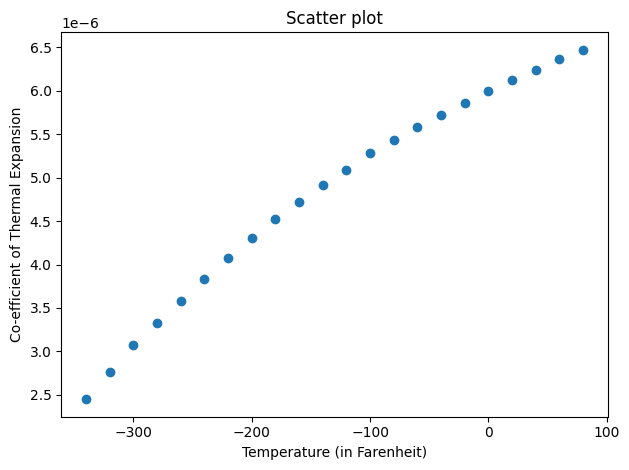

In [3]:
#plt.scatter(x, y, marker='s')
plt.scatter(temperature, alpha)
plt.xlabel("Temperature (in Farenheit)")
plt.ylabel("Co-efficient of Thermal Expansion")
plt.title("Scatter plot")

plt.tight_layout()
plt.show()

In [4]:
eta = 0.1       # learning rate
eps = 1.e-6     # Stopping tolerance

# Linear Model

In [5]:
x = temperature
y = alpha

C:\Users\adeet\AppData\Local\Temp\ipykernel_14348\3381505206.py:30: RuntimeWarning: overflow encountered in square
  cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
C:\Users\adeet\AppData\Local\Temp\ipykernel_14348\3381505206.py:33: RuntimeWarning: invalid value encountered in scalar subtract
  error = abs(C[-1] - C[-2])


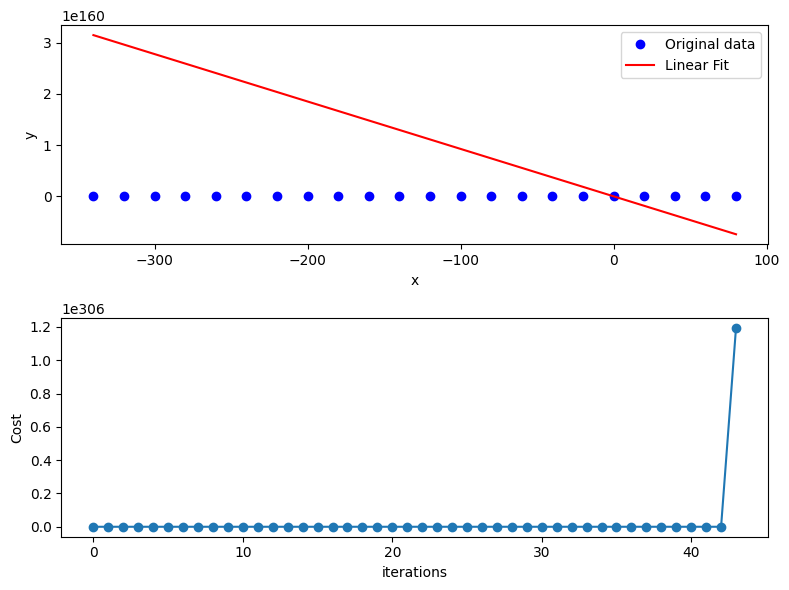

Number of iterations = 45
w0 = 3.6496674089765064e+155
w1 = -9.264403379118908e+157


In [6]:
eta = 0.1

# Initialize weights
w0 = rng.random()
w1 = rng.random()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

error = 1
iter = 0

while error > eps:

    yhat = w0 + w1*x

    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error = abs(C[-1] - C[-2])

yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

print(f"Number of iterations = {iter}")

# Learned weights
print(f"w0 = {w0}")
print(f"w1 = {w1}")

## Numerical explosion (Overflow)

We’re seeing numerical explosion (overflow) during gradient descent — and our plots confirm it (cost suddenly shooting to ~1e299 and line slope blowing up to ~1e157).

$x = temperature = [-340, -320, \cdots, 80]$

$y ≈ 2e-6$ to $6e-6$

This mismatch causes gradient terms like $(y - yhat) x$ to become huge, especially when $w_1$ grows.

Update rule:

$$w_1 = w_1 - η * gradient$$

But your gradient contains x → large values →
➡️ updates become massive jumps

This leads to:

weights → explode
predictions → explode
cost → overflow → inf → nan

## Fix 1: Normalize input $x$

In [7]:
x = (temperature - np.mean(temperature)) / np.std(temperature)

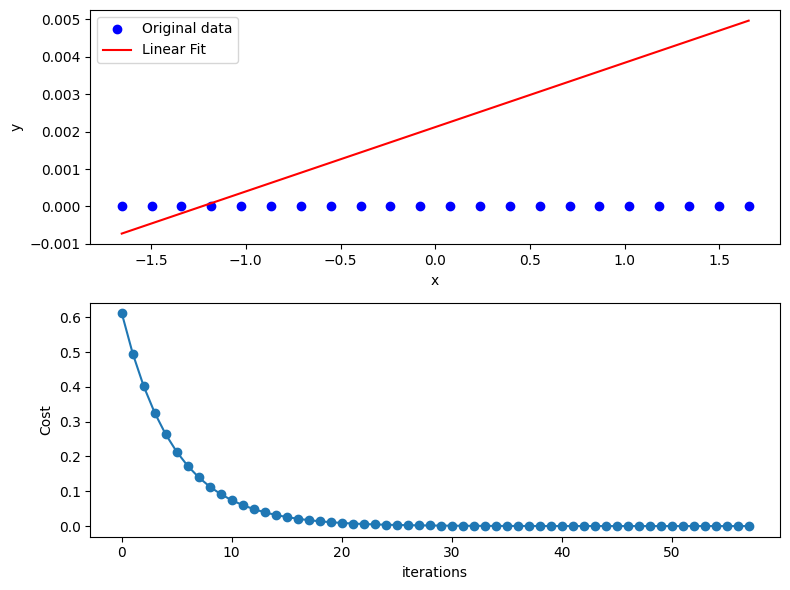

Number of iterations = 57
w0 = 0.0021212663722696232
w1 = 0.0017202245075435647


In [8]:
eta = 0.1

# Initialize weights
w0 = rng.random()
w1 = rng.random()

yhat = w0 + w1*x

initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

error = 1
iter = 0

while error > eps:

    yhat = w0 + w1*x

    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error = abs(C[-1] - C[-2])

yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

print(f"Number of iterations = {iter}")

# Learned weights
print(f"w0 = {w0}")
print(f"w1 = {w1}")

Your optimization is now stable but the predicted model (red line) is not fitting the data well.

**Why**?

Our target values: $y ≈ 2e-6$ to $6e-6$

But your predictions: $yhat ≈ 0$ to $0.005$ 

That’s 1000x larger scale.

Y
We scaled only x but NOT y

So the model is trying to fit:

small y (~1e-6)
with weights initialized around ~1

➡️ This creates a mismatch → bad fit

## Fix : Normalize Output $y$ also

In [9]:
x = (temperature - np.mean(temperature)) / np.std(temperature)
y = (alpha - np.mean(alpha)) / np.std(alpha)

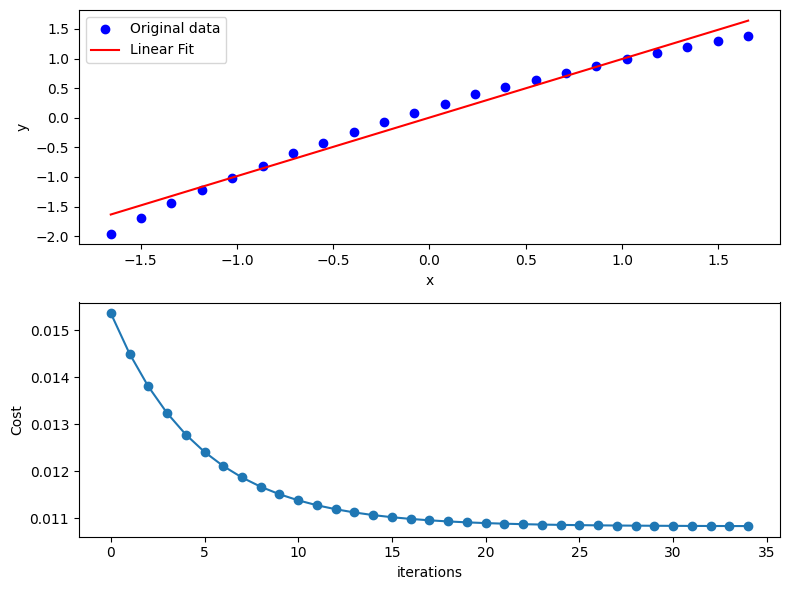

Number of iterations = 34
w0 = 0.0026193394090073653
w1 = 0.9887325713250155


In [10]:
eta = 0.1

# Initialize weights
w0 = rng.random()
w1 = rng.random()

yhat = w0 + w1*x
initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

error = 1
iter = 0

while error > eps:

    yhat = w0 + w1*x

    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    
    w0 = w0 + dw0
    w1 = w1 + dw1

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x)**2)
    C.append(cost)

    error = abs(C[-1] - C[-2])

yhat = w0 + w1*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Linear Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

print(f"Number of iterations = {iter}")

# Learned weights
print(f"w0 = {w0}")
print(f"w1 = {w1}")

## What our plots prove

**Top plot (fit)** 

- Data is now centered around 0 (because of normalization)
- Red line passes cleanly through the trend
- Slight deviations = noise / imperfect linearity 

This means: Our model has learned the correct relationship.

**Bottom plot (cost)**

- Smooth monotonic decrease
- Rapid drop initially
- Then gradual convergence 

Classic gradient descent behavior:
- Large gradients at start → fast learning
- Small gradients later → fine tuning

Since we normalized both $x$ and $y$, our model is effectively learning:
$$ y_{norm} = w_0 + w_1 x_{norm} $$

In normalized space:
- $w_0 \approx 0$ (because data is centered)
- $w_1 \approx 1$ (strong linear correlation)

# Quadratic Model

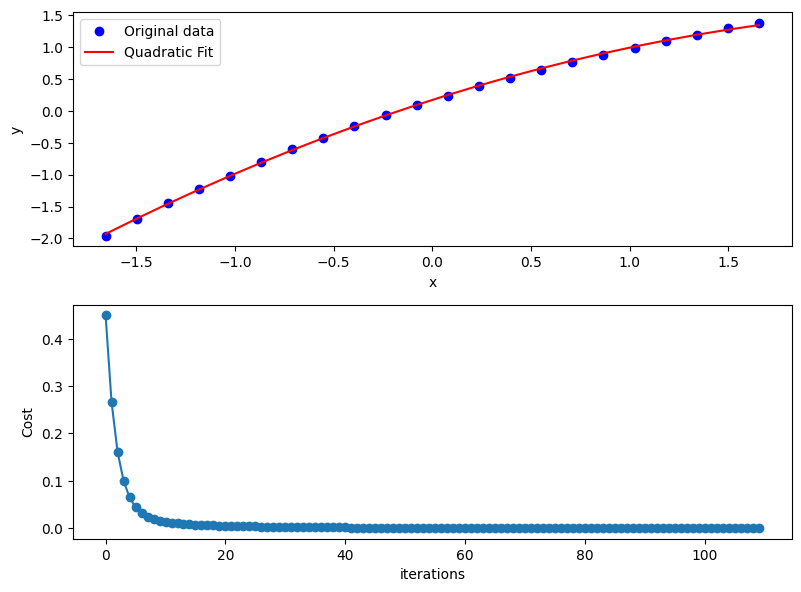

Number of iterations = 109
w0 = 0.17191164543978882
w1 = 0.9891055459458192
w2 = -0.16941879490507025


In [11]:
# learning rate
eta = 0.1

# Normalized inputs & outputs
x = (temperature - np.mean(temperature)) / np.std(temperature)
y = (alpha - np.mean(alpha)) / np.std(alpha)

# Initialize weights
w0 = rng.random()
w1 = rng.random()
w2 = rng.random()

yhat = w0 + w1*x + w2*x*x
initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

error = 1
iter = 0

while error > eps:

    yhat = w0 + w1*x + w2*x*x

    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    nabla_w2 = -np.sum((y - yhat) * x * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    dw2 = -eta*nabla_w2
    
    w0 = w0 + dw0
    w1 = w1 + dw1
    w2 = w2 + dw2

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x - w2*x*x)**2)
    C.append(cost)

    error = abs(C[-1] - C[-2])

yhat = w0 + w1*x + w2*x*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Quadratic Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

print(f"Number of iterations = {iter}")
print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"w2 = {w2}")

**Linear vs Polynomial Regression**:

Even though this looks “nonlinear”, it is still linear in parameters because 
$$ y = w_0 + w_1 x + w_2 x^2 $$
is linear in $w_0$, $w_1$ and $w_2$. Hence, the Gradient descent works the same way

## Polynomial Model

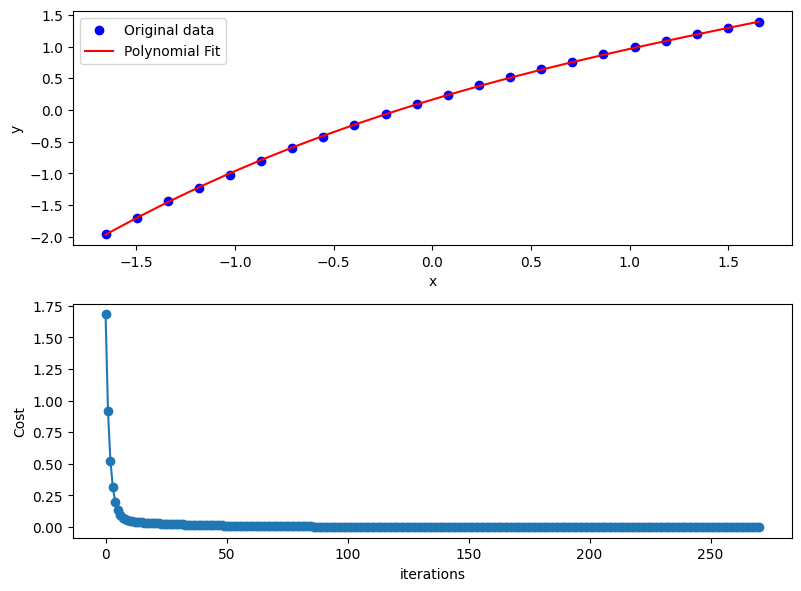

Number of iterations = 270
w0 = 0.16410957197349127
w1 = 0.9337536698509269
w2 = -0.1641243297267416
w3 = 0.029268001136565736


In [12]:
# learning rate
eta = 0.1

# Normalized inputs & outputs
x = (temperature - np.mean(temperature)) / np.std(temperature)
y = (alpha - np.mean(alpha)) / np.std(alpha)

# Initialize weights
w0 = rng.random()
w1 = rng.random()
w2 = rng.random()
w3 = rng.random()

yhat = w0 + w1*x + w2*x*x + w3*x*x*x
initial_cost = (0.5 / m)*np.sum((y - yhat)**2)
C = [initial_cost]

error = 1
iter = 0

while error > eps:

    yhat = w0 + w1*x + w2*x*x + w3*x*x*x

    nabla_w0 = -np.sum(y - yhat) / m
    nabla_w1 = -np.sum((y - yhat) * x) / m
    nabla_w2 = -np.sum((y - yhat) * x * x) / m
    nabla_w3 = -np.sum((y - yhat) * x * x * x) / m
    
    dw0 = -eta*nabla_w0
    dw1 = -eta*nabla_w1
    dw2 = -eta*nabla_w2
    dw3 = -eta*nabla_w3
    
    w0 = w0 + dw0
    w1 = w1 + dw1
    w2 = w2 + dw2
    w3 = w3 + dw3

    iter += 1

    cost = (0.5 / m)*np.sum((y - w0 - w1*x - w2*x*x - w3*x*x*x)**2)
    C.append(cost)

    error = abs(C[-1] - C[-2])

yhat = w0 + w1*x + w2*x*x + w3*x*x*x

# Create a new plotting canvas/figure with 8 inches width and 6 inches height
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Polynomial Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.subplot(212)
plt.plot(range(len(C)), C, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

print(f"Number of iterations = {iter}")
print(f"w0 = {w0}")
print(f"w1 = {w1}")
print(f"w2 = {w2}")
print(f"w3 = {w3}")

Polynomical Regression can fit complex curves but has
- Overfitting risk
- Slower convergence
- Numerical instability (if not scaled)

## Clean Code

$$ \mathbf{X} = \left[\mathbf{1}, \mathbf{x}, \mathbf{x^2}\right] $$

$$ \mathbf{w} = \left[w_0, w_1, w_2\right]^T $$

$$ \mathbf{\hat{y}} = w_0 + w_1 \mathbf{x} + w_2 \mathbf{x^2}= \mathbf{X} \mathbf{w}$$

$$ \mathbf{c} = (y - \mathbf{\hat{y}} )^2 $$

$$ \nabla{\mathbf{c}} = \frac{1}{m} \left[\frac{\partial{\mathbf{c}}}{\partial{w_0}}, \frac{\partial{\mathbf{c}}}{\partial{w_1}}, \frac{\partial{\mathbf{c}}}{\partial{w_2}}\right]^T $$

$$ \nabla{\mathbf{c}} = \frac{1}{m} \left[-(y - \mathbf{\hat{y}}), -\mathbf{x}^T(y - \mathbf{\hat{y}}), -\mathbf{x^2}^T(y - \mathbf{\hat{y}})\right] $$

$$ \nabla{\mathbf{c}} = -\frac{1}{m} \mathbf{X}^T  (\mathbf{y} - \mathbf{\hat{y}})$$

$$ \mathbf{w} = \mathbf{w} + \mathbf{dw} $$

$$ \mathbf{w} = \mathbf{w} -\eta  \nabla{\mathbf{c}} $$

In [13]:
def create_polynomial_features(x, degree):
    return np.vstack([x**i for i in range(degree + 1)]).T

def compute_cost(X, y, w):
    m = len(y)
    return (0.5 / m) * np.sum((y - X @ w)**2)

def gradient_descent(X, y, eta=0.1, eps=1e-6, max_iters=10000):
    m, n = X.shape
    w = rng.random(n)

    cost_history = []
    cost_change = 1
    num_iters = 0

    while cost_change > eps and num_iters < max_iters:
        
        yhat = X @ w
        # yhat = np.dot(X, w)
        
        gradient = -(X.T @ (y - yhat)) / m
        w = w - eta * gradient

        cost = compute_cost(X, y, w)
        cost_history.append(cost)

        if len(cost_history) > 1:
            cost_change = abs(cost_history[-1] - cost_history[-2])

        num_iters += 1

    return w, cost_history, num_iters

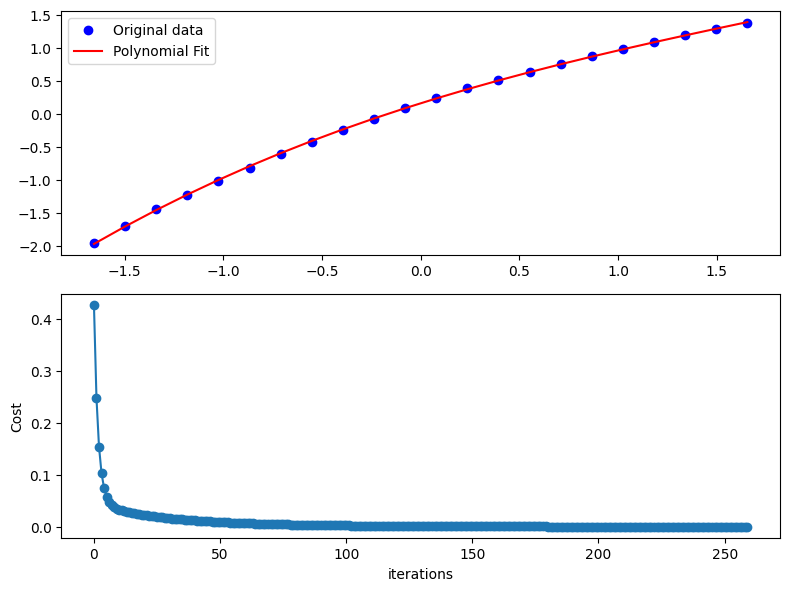

Weights: [ 0.16421059  0.93398529 -0.16419288  0.02915554]
Iterations: 260


In [14]:
# Normalize
x = (temperature - np.mean(temperature)) / np.std(temperature)
y = (alpha - np.mean(alpha)) / np.std(alpha)

degree = 3
X = create_polynomial_features(x, degree)

w, cost_history, num_iters = gradient_descent(X, y)

# Matrix multiplication (same as np.dot(X, w))
# yhat = X @ w
yhat = np.dot(X, w)

# Plot
plt.figure(figsize=(8, 6))

plt.subplot(211)
plt.plot(x, y, 'bo', label="Original data")
plt.plot(x, yhat, 'r-', label="Polynomial Fit")
plt.legend()

plt.subplot(212)
plt.plot(cost_history, '-o')
plt.xlabel("iterations")
plt.ylabel("Cost")

plt.tight_layout()
plt.show()

print("Weights:", w)
print("Iterations:", num_iters)